In [12]:
from sklearn.preprocessing import StandardScaler
from utils.evaluation import *
from utils.load_data import load_processed_data
from models.dnn import DNN
from models.linear_regression import LinearRegressionSklearn 
import torch
from torch.utils.data import DataLoader, Dataset

## Load data

In [13]:
data_path = '../data/processed'
X_train, X_val, X_test, y_train, y_val, y_test = load_processed_data(data_path)

X_train shape: torch.Size([2132, 30]), y_train shape: torch.Size([2132, 1])
X_val shape: torch.Size([457, 30]), y_val shape: torch.Size([457, 1])
X_test shape: torch.Size([458, 30]), y_test shape: torch.Size([458, 1])


In [14]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [15]:
batch_size = 64

train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Training and Evaluation

#### Hyperparameters

In [16]:
epochs = 300
learning_rate = 0.1
dropout = 0.0
batch_norm = True
l2_lambda = 0
weight_decay = 0.0
grad_clip = False
activation = 'leaky_relu'

In [17]:
def pipeline(
        model, 
        epochs=50, 
        verbose=True, 
        early_stopping=False, 
        patience=10, 
        grad_clip=True, 
        title=None,
):
    train_losses, val_losses = model.fit(
        train_loader, 
        val_loader, 
        epochs=epochs, 
        verbose=verbose, 
        early_stopping=early_stopping, 
        patience=patience, 
        grad_clip=grad_clip
    )
    test_model(model, X_test, y_test)
    if title is None:
        title = f'{model.__class__.__name__}'
    plot_loss(train_losses, val_losses, log=True, title=title)

### Linear Regression

In [18]:
lr = LinearRegressionSklearn()
lr.fit(X_train, y_train)
test_model(lr, X_test, y_test)


=========== Model Evaluation ===========
Mean Absolute Error (MAE): 10.5178
Mean Squared Error (MSE): 201.2833
R^2 Score: 0.7466


### DNN-16

In [19]:
dnn_16 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[16],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation, 
    weight_decay=weight_decay,
)
dnn_16.model

Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [30/300], Train Loss: 323.0526, Val Loss: 334.7893
Epoch [60/300], Train Loss: 268.4481, Val Loss: 312.4600
Epoch [90/300], Train Loss: 245.5224, Val Loss: 298.4412
Epoch [120/300], Train Loss: 237.1662, Val Loss: 221.0598
Epoch [150/300], Train Loss: 227.5787, Val Loss: 330.7465
Epoch [180/300], Train Loss: 222.2014, Val Loss: 229.4137
Epoch [210/300], Train Loss: 215.1294, Val Loss: 308.5402
Epoch [240/300], Train Loss: 213.4363, Val Loss: 209.7830
Epoch [270/300], Train Loss: 208.5990, Val Loss: 305.2468
Epoch [300/300], Train Loss: 198.8609, Val Loss: 212.2993

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 13.3821
Mean Squared Error (MSE): 284.6617
R^2 Score: 0.6416


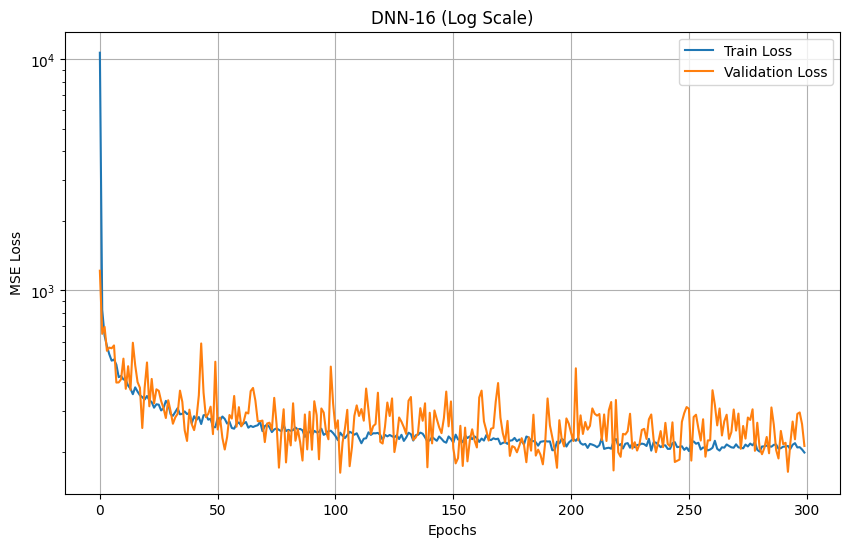

In [20]:
pipeline(dnn_16, epochs=epochs, title='DNN-16')

## DNN-30-8

In [21]:
dnn_30_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
)
dnn_30_8.model

Sequential(
  (0): Linear(in_features=30, out_features=30, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=30, out_features=8, bias=True)
  (3): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [30/300], Train Loss: 198.5184, Val Loss: 293.1007
Epoch [60/300], Train Loss: 161.5097, Val Loss: 416.3535
Epoch [90/300], Train Loss: 163.1296, Val Loss: 200.6823
Epoch [120/300], Train Loss: 150.3480, Val Loss: 365.2176
Epoch [150/300], Train Loss: 152.6674, Val Loss: 201.6461
Epoch [180/300], Train Loss: 145.2323, Val Loss: 234.5421
Epoch [210/300], Train Loss: 133.2369, Val Loss: 194.8398
Epoch [240/300], Train Loss: 148.2030, Val Loss: 183.7356
Epoch [270/300], Train Loss: 138.1538, Val Loss: 189.5721
Epoch [300/300], Train Loss: 124.5925, Val Loss: 384.6647

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 14.7659
Mean Squared Error (MSE): 358.8473
R^2 Score: 0.5482


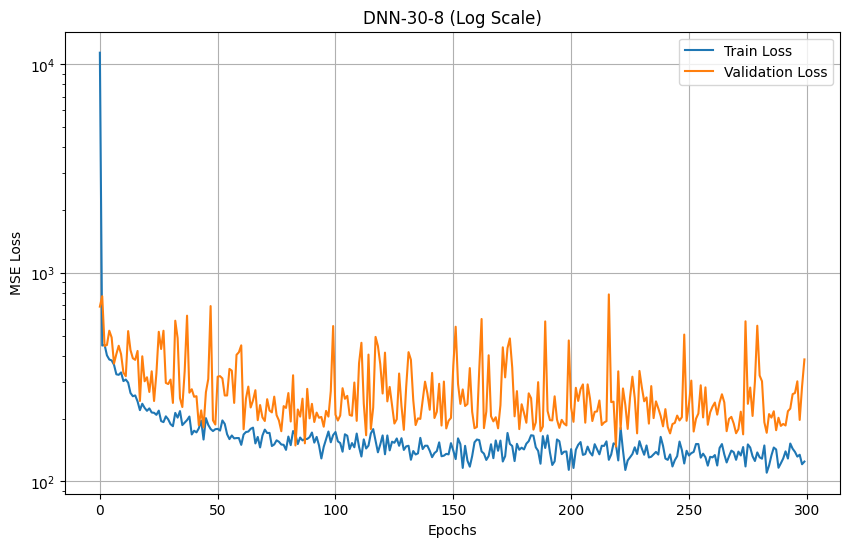

In [22]:
pipeline(dnn_30_8, epochs=epochs, title='DNN-30-8')

## DNN-30-16-8

In [23]:
dnn_30_16_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
)
dnn_30_16_8.model

Sequential(
  (0): Linear(in_features=30, out_features=30, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Linear(in_features=16, out_features=8, bias=True)
  (6): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [30/300], Train Loss: 204.6453, Val Loss: 283.4658
Epoch [60/300], Train Loss: 149.5982, Val Loss: 272.3052
Epoch [90/300], Train Loss: 162.6174, Val Loss: 168.1845
Epoch [120/300], Train Loss: 149.8574, Val Loss: 188.8340
Epoch [150/300], Train Loss: 143.5532, Val Loss: 177.7706
Epoch [180/300], Train Loss: 123.0825, Val Loss: 290.1698
Epoch [210/300], Train Loss: 131.3911, Val Loss: 244.6634
Epoch [240/300], Train Loss: 101.2973, Val Loss: 253.8938
Epoch [270/300], Train Loss: 115.7728, Val Loss: 231.9255
Epoch [300/300], Train Loss: 113.3114, Val Loss: 172.7974

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 11.3277
Mean Squared Error (MSE): 217.3910
R^2 Score: 0.7263


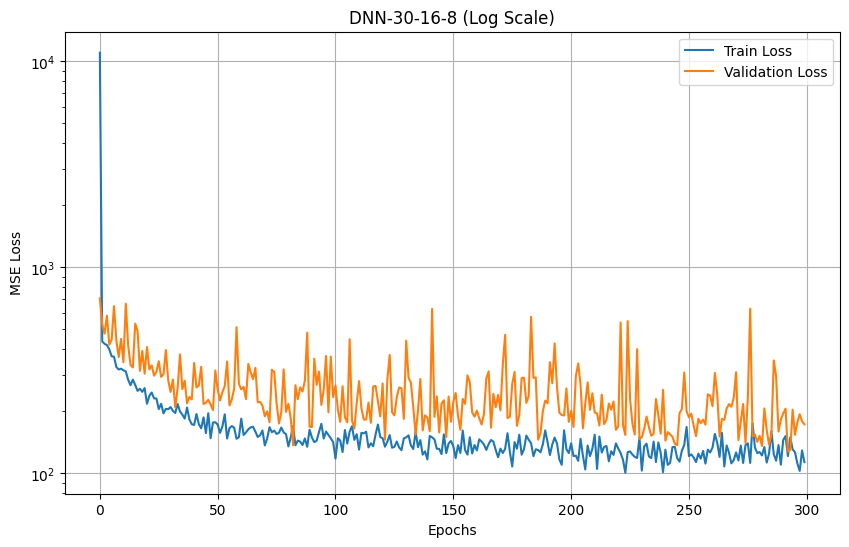

In [24]:
pipeline(dnn_30_16_8, epochs=epochs, title='DNN-30-16-8')

## DNN-30-16-8-4

In [25]:
dnn_30_16_8_4 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8, 4],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
)
dnn_30_16_8_4.model

Sequential(
  (0): Linear(in_features=30, out_features=30, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Linear(in_features=16, out_features=8, bias=True)
  (6): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=8, out_features=4, bias=True)
  (9): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): LeakyReLU(negative_slope=0.01)
  (11): Linear(in_features=4, out_features=1, bias=True)
)

Epoch [30/300], Train Loss: 218.8691, Val Loss: 288.4513
Epoch [60/300], Train Loss: 153.4777, Val Loss: 336.9179
Epoch [90/300], Train Loss: 171.4400, Val Loss: 236.0299
Epoch [120/300], Train Loss: 142.0847, Val Loss: 178.2651
Epoch [150/300], Train Loss: 123.9775, Val Loss: 169.3421
Epoch [180/300], Train Loss: 142.8915, Val Loss: 210.8633
Epoch [210/300], Train Loss: 125.4654, Val Loss: 178.7093
Epoch [240/300], Train Loss: 134.8499, Val Loss: 443.3404
Epoch [270/300], Train Loss: 134.1790, Val Loss: 227.3810
Epoch [300/300], Train Loss: 111.5525, Val Loss: 223.9242

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 12.7890
Mean Squared Error (MSE): 295.6414
R^2 Score: 0.6277


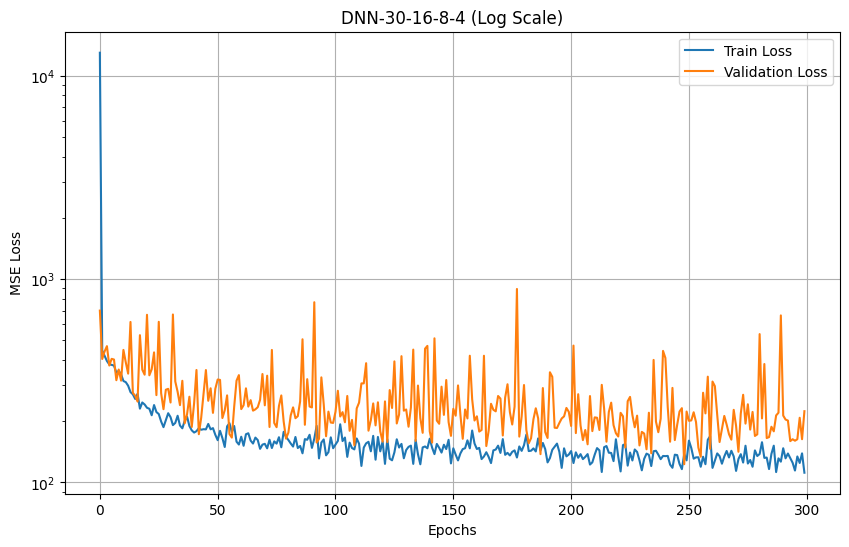

In [26]:
pipeline(dnn_30_16_8_4, epochs=epochs, title='DNN-30-16-8-4')

## Custom DNN

In [27]:
custom_dnn = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[128, 64, 32, 16],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
)
custom_dnn.model

Sequential(
  (0): Linear(in_features=30, out_features=128, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Linear(in_features=64, out_features=32, bias=True)
  (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=32, out_features=16, bias=True)
  (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): LeakyReLU(negative_slope=0.01)
  (11): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [30/300], Train Loss: 138.0813, Val Loss: 259.3932
Epoch [60/300], Train Loss: 116.1851, Val Loss: 249.0315
Epoch [90/300], Train Loss: 121.0455, Val Loss: 277.1752
Epoch [120/300], Train Loss: 131.2048, Val Loss: 271.2389
Epoch [150/300], Train Loss: 105.9466, Val Loss: 224.1038
Epoch [180/300], Train Loss: 104.0869, Val Loss: 268.0393
Epoch [210/300], Train Loss: 97.1490, Val Loss: 361.5072
Epoch [240/300], Train Loss: 101.2855, Val Loss: 213.7707
Epoch [270/300], Train Loss: 100.5062, Val Loss: 186.7879
Epoch [300/300], Train Loss: 85.7114, Val Loss: 213.9216

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 10.6660
Mean Squared Error (MSE): 222.0678
R^2 Score: 0.7204


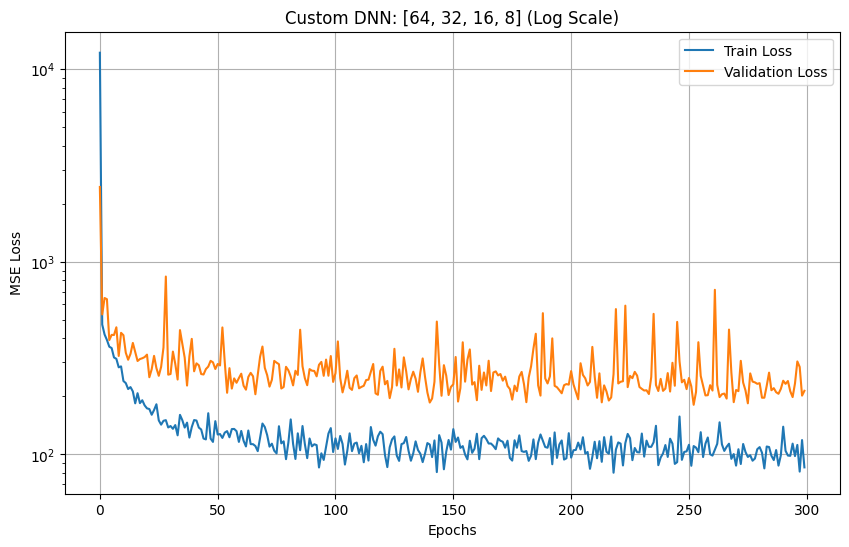

In [28]:
pipeline(custom_dnn, epochs=epochs, title='Custom DNN: [64, 32, 16, 8]')